<a href="https://colab.research.google.com/github/IsuPaul/Indpendent-Research/blob/IR_Codes/IR_Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ENHANCED MACHINE LEARNING MODEL FOR 3D PRINTING CONCRETE COMPRESSIVE STRENGTH PREDICTION

## Imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xbt
import matplotlib.pyplot as plt
import shap
from sklearn.utils import resample
from sklearn.preprocessing import scale
from sklearn.tree import DecisionTreeRegressor
from sklearn import svm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import kernels, GaussianProcessRegressor
from sklearn.inspection import PartialDependenceDisplay

## DATA MANAGEMENT AND CLEANING

### Visualization and Description of Uncleaned Data

In [2]:
df = pd.read_csv('Datasets.csv', encoding='latin-1')

In [3]:
#df.head()

In [4]:
#df.describe()

### Determining the type of data in each column

In [5]:
#df.dtypes

### Converting all data to float

In [6]:
df['Carbonated RFA (Kg)']=df['Carbonated RFA (Kg)'].astype(float)
df['PP (Kg)']=df['PP (Kg)'].astype(float)
df['Silica Powder (Kg)']=df['Silica Powder (Kg)'].astype(float)
df['AT (Kg)']=df['AT (Kg)'].astype(float)
#df.dtypes

### Checking for missing data

In [7]:
#df.isnull().sum()

### Fixing Missing Data

In [8]:
imputer_gbt = IterativeImputer(max_iter=10, random_state=42)
imputed_data=imputer_gbt.fit_transform(df)
imputed_data = np.maximum(imputed_data, 0)
imputed_df=pd.DataFrame(imputed_data,columns=df.columns)

### Reconfirm to check for missing data

In [9]:
#imputed_df.isnull().sum()

### Features Distributions

In [10]:
for i in imputed_df.columns:
    plt.figure(figsize=(2.5, 2.5))
    plt.hist(imputed_df[i])
    plt.xlabel(f"{i}",fontsize=7)
    plt.ylabel("Frequency",fontsize=7)
    plt.title(" ")
    plt.tight_layout()
    plt.savefig(f"{i.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.jpg")
    plt.close('all')

## MODEL DEVELOPEMENTS

### EXTREME GRADIENT BOOSTING

#### Assigning Variables

In [11]:
X=imputed_df.drop('Compressive Strength (MPa)',axis=1).copy()
y=imputed_df['Compressive Strength (MPa)'].copy()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

#### Training the model

In [13]:
clf=xbt.XGBRegressor()
clf.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

#### Model Validation

#### Evaluation of Training Data

In [14]:
y_pred = clf.predict(X_train)
mse=mean_squared_error(y_train, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_train, y_pred)
maer_xA=mean_absolute_error(y_train, y_pred)
print("Mean Absolute Error:", maer_xA)
print("Root Mean Squared Error:", rmse)
print("R-Squared Score:", r2)

Mean Absolute Error: 0.6202199883866816
Root Mean Squared Error: 1.5965955626174413
R-Squared Score: 0.9967168480685068


#### Evaluation of Testing Data

In [15]:
y_pred = clf.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)
maer_xA=mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", maer_xA)
print("Root Mean Squared Error:", rmse)
print("R-Squared Score:", r2)

Mean Absolute Error: 3.4798958325090488
Root Mean Squared Error: 4.880272101388487
R-Squared Score: 0.9712921297809599


#### Model Optimization (Hyperparameter Tunning)

In [16]:
parameters={ 'learning_rate': [0.2] , 'max_depth':  [4] , 'n_estimators': [1000] }
model= xbt.XGBRegressor()
grid_model=GridSearchCV(model, parameters, cv=10, scoring="neg_mean_squared_error")
grid_model.fit(X_train, y_train)
print("Best set of hyperparameters: ",grid_model.best_params_)
print("Best score: ",grid_model.best_score_)

Best set of hyperparameters:  {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 1000}
Best score:  -71.92635295767641


##### Evaluation of Training Data

In [17]:
best_model= grid_model.best_estimator_
y_predict=best_model.predict(X_train)
mse1=mean_squared_error(y_train, y_predict)
rmse1=np.sqrt(mse1)
r21=r2_score(y_train, y_predict)
maer_x=mean_absolute_error(y_train, y_predict)
print("Mean Absolute Error:", maer_x)
print("Root Mean Squared Error:", rmse1)
print("R-Squared Score:", r21)

Mean Absolute Error: 0.48285498715038844
Root Mean Squared Error: 1.5769628829451252
R-Squared Score: 0.9967970947767296


##### Evaluation of Testing Data

In [18]:
best_model= grid_model.best_estimator_
y_predict=best_model.predict(X_test)
mse1=mean_squared_error(y_test, y_predict)
rmse1=np.sqrt(mse1)
r21=r2_score(y_test, y_predict)
maer_x=mean_absolute_error(y_test, y_predict)
print("Mean Absolute Error:", maer_x)
print("Root Mean Squared Error:", rmse1)
print("R-Squared Score:", r21)

Mean Absolute Error: 3.3600906478373473
Root Mean Squared Error: 4.7837082709127525
R-Squared Score: 0.9724169508033963


### SUPPORT VECTOR MACHINE MODEL

#### Scaling the dataframe

In [19]:
sdf=(imputed_df-imputed_df.min())/(imputed_df.max()-imputed_df.min())

#### Assigning variables for the model

In [20]:
X_svm=sdf.drop('Compressive Strength (MPa)',axis=1).copy()
y_svm=sdf['Compressive Strength (MPa)'].copy()

In [21]:
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_svm, y_svm, test_size=0.3,random_state=42)

In [22]:
model_svm = svm.SVR()

#### Training the model

In [23]:
model_svm.fit(Xs_train, ys_train)

SVR()

#### Model Validation

##### Evaluation of Training Data

In [24]:
ys_pred = model_svm.predict(Xs_train)
mses=mean_squared_error(ys_train, ys_pred)
rmses=np.sqrt(mses)
r2s=r2_score(ys_train, ys_pred)
maer_xs=mean_absolute_error(ys_train, ys_pred)
print("Mean Absolute Error:", maer_xs)
print("Root Mean Squared Error:", rmses)
print("R-Squared Score:", r2s)

Mean Absolute Error: 0.055019823591760136
Root Mean Squared Error: 0.0642131212353541
R-Squared Score: 0.8505576241992818


##### Evaluation of Testing Data

In [25]:
ys_pred = model_svm.predict(Xs_test)
mses=mean_squared_error(ys_test, ys_pred)
rmses=np.sqrt(mses)
r2s=r2_score(ys_test, ys_pred)
maer_xs=mean_absolute_error(ys_test, ys_pred)
print("Mean Absolute Error:", maer_xs)
print("Root Mean Squared Error:", rmses)
print("R-Squared Score:", r2s)

Mean Absolute Error: 0.061357776837041855
Root Mean Squared Error: 0.07220429126822395
R-Squared Score: 0.8231667304037942


### RANDOM FOREST

#### Assigning variables for the model

In [26]:
model_rf=RandomForestRegressor(random_state=42)

#### Training the model

In [27]:
model_rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

#### Model Validation

##### Evaluation of Training Data

In [28]:
yr_pred = model_rf.predict(X_train)
mser=mean_squared_error(y_train, yr_pred)
rmser=np.sqrt(mser)
maer=mean_absolute_error(y_train, yr_pred)
r2r=r2_score(y_train, yr_pred)
print("Mean Absolute Error:", maer)
print("Root Mean Squared Error:", rmser)
print("R-Squared Score:", r2r)

Mean Absolute Error: 2.076068773922095
Root Mean Squared Error: 3.3235617534275126
R-Squared Score: 0.9857731533597593


##### Evaluation of Testing Data

In [29]:
yr_pred = model_rf.predict(X_test)
mser=mean_squared_error(y_test, yr_pred)
rmser=np.sqrt(mser)
maer=mean_absolute_error(y_test, yr_pred)
r2r=r2_score(y_test, yr_pred)
print("Mean Absolute Error:", maer)
print("Root Mean Squared Error:", rmser)
print("R-Squared Score:", r2r)

Mean Absolute Error: 3.9814030493244124
Root Mean Squared Error: 5.821562666686459
R-Squared Score: 0.9591500006449265


### DECISION TREE

#### Assigning variables for the model

In [30]:
model_dt=DecisionTreeRegressor()

#### Training the model

In [31]:
model_dt.fit(X_train, y_train)

DecisionTreeRegressor()

#### Model Validation

##### Evaluation of Training Data

In [32]:
yd_pred = model_dt.predict(X_train)
msed=mean_squared_error(y_train, yd_pred)
rmsed=np.sqrt(msed)
maed=mean_absolute_error(y_train, yd_pred)
r2d=r2_score(y_train, yd_pred)
print("Mean Absolute Error:", maed)
print("Root Mean Squared Error:", rmsed)
print("R-Squared Score:", r2d)

Mean Absolute Error: 0.4761761229314422
Root Mean Squared Error: 1.5769048858166843
R-Squared Score: 0.9967973303636185


##### Evaluation of Testing Data

In [33]:
yd_pred = model_dt.predict(X_test)
msed=mean_squared_error(y_test, yd_pred)
rmsed=np.sqrt(msed)
maed=mean_absolute_error(y_test, yd_pred)
r2d=r2_score(y_test, yd_pred)
print("Mean Absolute Error:", maed)
print("Root Mean Squared Error:", rmsed)
print("R-Squared Score:", r2d)

Mean Absolute Error: 4.687685950413224
Root Mean Squared Error: 7.45977320733458
R-Squared Score: 0.9329244644629062


### MULTILINEAR REGRESSION

#### Assigning variables for the model

In [34]:
model_ml=LinearRegression()

#### Training the model

In [35]:
model_ml.fit(X_train, y_train)

LinearRegression()

#### Model Validation

##### Evaluation of Training Data

In [36]:
ym_pred = model_ml.predict(X_train)
msem=mean_squared_error(y_train, ym_pred)
rmsem=np.sqrt(msem)
maem=mean_absolute_error(y_train, ym_pred)
r2m=r2_score(y_train, ym_pred)
print("Mean Absolute Error:", maem)
print("Root Mean Squared Error:", rmsem)
print("R-Squared Score:", r2m)

Mean Absolute Error: 5.755305081158454
Root Mean Squared Error: 8.026372411859414
R-Squared Score: 0.9170264335402404


##### Evaluation of Testing Data

In [37]:
ym_pred = model_ml.predict(X_test)
msem=mean_squared_error(y_test, ym_pred)
rmsem=np.sqrt(msem)
maem=mean_absolute_error(y_test, yd_pred)
r2m=r2_score(y_test, ym_pred)
print("Mean Absolute Error:", maem)
print("Root Mean Squared Error:", rmsem)
print("R-Squared Score:", r2m)

Mean Absolute Error: 4.687685950413224
Root Mean Squared Error: 9.324827820736402
R-Squared Score: 0.8951919735267084


In [38]:
print(f'Coefficients: {model_ml.coef_}')
print(f'Intercept: {model_ml.intercept_}')

Coefficients: [ 8.54677925e-02 -1.98464151e-01 -2.04656968e-04  1.15204360e-01
  5.28759414e-02  3.62636686e-01 -8.13930750e-02  2.82634000e+00
  1.67490465e+00 -5.08885768e+00 -5.88227367e-01  2.70492234e-02
 -1.36280241e+00  4.76442130e+00  2.10285228e+01 -7.57679576e+00
  1.69828958e+01 -1.31072220e-02  1.89213637e-02  7.17344131e-02
  4.53935621e-01 -6.71390269e-01  6.83590780e-02 -3.26390806e+00
 -6.34179043e-03 -1.18515055e-01 -6.93899122e-02 -8.89092011e-03
 -3.40934153e-01 -1.32016734e+00 -3.09978680e+00  4.67813746e+01
 -8.80936931e-03 -1.24469547e+01 -1.25812981e-02  1.42322228e-02
 -2.32807586e+01]
Intercept: 29.90325858298452


### KNN NEIGHBORS

#### Assigning variables for the model

In [39]:
model_kn=KNeighborsRegressor(2)

#### Training the model

In [40]:
model_kn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=2)

#### Model Validation

##### Evaluation of Training Data

In [41]:
yk_pred = model_kn.predict(X_train)
msek=mean_squared_error(y_train, yk_pred)
rmsek=np.sqrt(msek)
maek=mean_absolute_error(y_train, yk_pred)
r2k=r2_score(y_train, yk_pred)
print("Mean Absolute Error:", maek)
print("Root Mean Squared Error:", rmsek)
print("R-Squared Score:", r2k)

Mean Absolute Error: 4.084716312056738
Root Mean Squared Error: 6.638903053616549
R-Squared Score: 0.9432332803739331


##### Evaluation of Testing Data

In [42]:
yk_pred = model_kn.predict(X_test)
msek=mean_squared_error(y_test, yk_pred)
rmsek=np.sqrt(msek)
maek=mean_absolute_error(y_test, yk_pred)
r2k=r2_score(y_test, yk_pred)
print("Mean Absolute Error:", maek)
print("Root Mean Squared Error:", rmsek)
print("R-Squared Score:", r2k)

Mean Absolute Error: 7.5978471074380165
Root Mean Squared Error: 13.098847002678777
R-Squared Score: 0.7931864262041165


## VISUALIZATION OF MODEL PERFORMANCE

### SHAP ANALYSIS

In [43]:
# SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

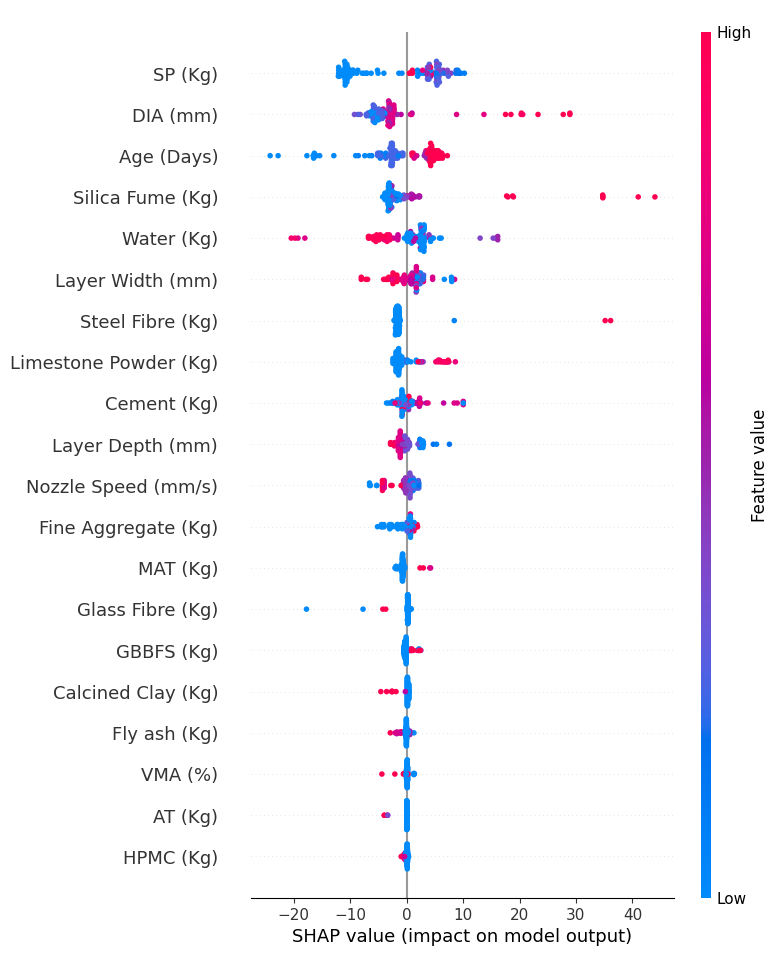

In [44]:
# Plot SHAP summary with minimized height
plt.figure(figsize=(4, 4))  # Adjusted height to minimize the plot size
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)  # Set show=False to prevent auto-display
plt.gca().set_title(" ")  # Optional: Set a title for clarity
plt.savefig("SHAP1.jpg")
#plt.show()

In [45]:
exp=shap.Explainer(best_model)
shap_values = exp(X_test)
plt.figure(figsize=(3.2, 3.4))
shap.plots.waterfall(shap_values[104], show=False)
plt.tight_layout()
plt.savefig("WATERFALL.jpg")
plt.close()

In [46]:
plt.figure(figsize=(4, 2))
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("BAR_IMPORTANCE.jpg")
plt.close()

In [47]:
#Partial Dependence Plot (PDP)
for i in X_test.columns:
    fig, ax = plt.subplots(figsize=(3.5, 3.5)) # Create figure and axes objects
    PartialDependenceDisplay.from_estimator(best_model, X_test, [i], ax=ax) # Pass axes to display
    ax.set_xlabel(f"{i}", fontsize=8) # Use ax.set_xlabel instead of plt.xlabel
    ax.set_ylabel("Partial Dependence", fontsize=8) # Use ax.set_ylabel instead of plt.ylabel
    ax.set_title(f" ") # Use ax.set_title instead of plt.title
    plt.tight_layout()
    plt.savefig(f" PDP of {i.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.jpg")
    plt.close(fig) # Close the figure objec

/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-p

### Scatter Plot of XGBOOST

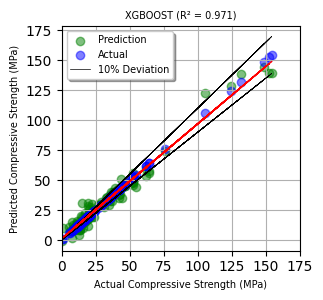

In [48]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=1)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"XGBOOST (R² = {r2:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_XGBOOST.jpg")
plt.show()

### Scatter Plot of XGBOOST+

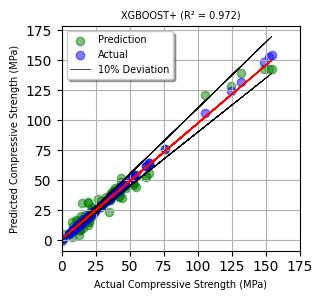

In [49]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_predict, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, y_predict, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=1)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"XGBOOST+ (R² = {r21:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_XGBOOST+.jpg")
plt.show()

### Scatter Plot of SVM Model

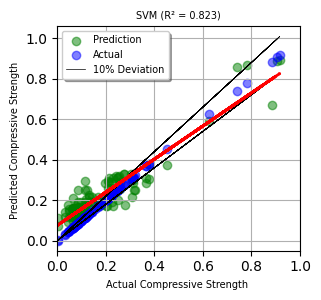

In [50]:
# Calculate the 10% deviation
deviation = 0.10 * ys_test
lower_bound = ys_test - deviation
upper_bound = ys_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(ys_test, ys_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(ys_test, ys_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(ys_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(ys_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(ys_test, ys_pred, 1)
plt.plot(ys_test, m * ys_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength ",fontsize=7)
plt.ylabel("Predicted Compressive Strength ",fontsize=7)
plt.title(f"SVM (R² = {r2s:.3f})",fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 1
interval = 0.2
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_SVM.jpg")
plt.show()

### Scatter Plot of RF Model

In [51]:
# Calculate the 10% deviation
deviation = 0.10 * yr_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, yr_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, yr_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"RF (R² = {r2r:.3f})",fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_RF.jpg")
plt.show()

NameError: name 'yr_test' is not defined

### Scatter Plot of DT Model

In [ ]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, yd_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"DT (R² = {r2d:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_DT.jpg")
plt.show()

### Scatter Plot of MLR Model

In [ ]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, ym_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)",fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)",fontsize=7)
plt.title(f"MLR (R² = {r2m:.3f})",fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_MLR.jpg")
plt.show()

### Scatter Plot of KNN Model

In [ ]:
# Calculate the 10% deviation
deviation = 0.10 * y_test
lower_bound = y_test - deviation
upper_bound = y_test + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test, yk_pred, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test, yk_pred, 1)
plt.plot(y_test, m * y_test + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"KNN (R² = {r2k:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_KNN.jpg")
plt.show()

### Material Model

In [ ]:
columns_to_remove = ['Nozzle Speed (mm/s)', 'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']
X_new = imputed_df.drop(columns_to_remove, axis=1).drop('Compressive Strength (MPa)', axis=1).copy()
y_new = imputed_df['Compressive Strength (MPa)'].copy()

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

#parameters_new={ 'learning_rate': [0.2] , 'max_depth':  [4] , 'n_estimators': [1000] }
#model_new= xbt.XGBRegressor()
#grid_model_new=GridSearchCV(model_new, parameters_new, cv=10, scoring="neg_mean_squared_error")
#grid_model_new.fit(X_train_new, y_train_new)
grid_model_new=xbt.XGBRegressor()
grid_model_new.fit(X_train_new, y_train_new)

# Use the grid_model to forecast the model
y_predict_new = grid_model_new.predict(X_test_new)

# Evaluate the model
mse_new = mean_squared_error(y_test_new, y_predict_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test_new, y_predict_new)
maer_new = mean_absolute_error(y_test_new, y_predict_new)

print("Mean Absolute Error:", maer_new)
print("Root Mean Squared Error:", rmse_new)
print("R-Squared Score:", r2_new)

#### Scatter Plot of Material Model

In [ ]:
# Calculate the 10% deviation
deviation = 0.10 * y_test_new
lower_bound = y_test_new - deviation
upper_bound = y_test_new + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test_new, y_predict_new, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test_new, y_test_new, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test_new, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test_new, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test_new, y_predict_new, 1)
plt.plot(y_test_new, m * y_test_new + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"Material Model (R² = {r2_new:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_Material.jpg")
plt.show()

### Printing Model

In [ ]:
X_new = imputed_df[['Nozzle Speed (mm/s)', 'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']].copy()
y_new = imputed_df['Compressive Strength (MPa)'].copy()

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.3, random_state=42
)
grid_model_new=xbt.XGBRegressor()
grid_model_new.fit(X_train_new, y_train_new)
# Use the grid_model to forecast the model
y_predict_new = grid_model_new.predict(X_test_new)

# Evaluate the model
mse_new = mean_squared_error(y_test_new, y_predict_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test_new, y_predict_new)
maer_new = mean_absolute_error(y_test_new, y_predict_new)

print("Mean Absolute Error:", maer_new)
print("Root Mean Squared Error:", rmse_new)
print("R-Squared Score:", r2_new)

#### Scatter Plot of Printing Model

In [ ]:
# Calculate the 10% deviation
deviation = 0.10 * y_test_new
lower_bound = y_test_new - deviation
upper_bound = y_test_new + deviation

# Create the plot with smaller figure size
plt.figure(figsize=(3.2, 3.1))

# Plot the prediction in green and actual in blue
plt.scatter(y_test_new, y_predict_new, color='green', alpha=0.5, label='Prediction')
plt.scatter(y_test_new, y_test_new, color='blue', alpha=0.5, label='Actual')

# Plot the 10% deviation lines
plt.plot(y_test_new, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
plt.plot(y_test_new, upper_bound, color='black', linewidth=0.5)

# Plot the line of best fit
m, b = np.polyfit(y_test_new, y_predict_new, 1)
plt.plot(y_test_new, m * y_test_new + b, 'r--', lw=2)

# Customize the plot
plt.xlabel("Actual Compressive Strength (MPa)", fontsize=7)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=7)
plt.title(f"Printing Model (R² = {r2_new:.3f})", fontsize=7)
plt.tight_layout()
# Set x-axis limits to start from zero
min_val = 0
max_val = 175
interval = 25
plt.xlim(min_val, max_val)
plt.xticks(np.arange(min_val, max_val + interval, interval))
plt.grid(True)
plt.legend(fontsize=7, shadow=True, facecolor='white')
plt.savefig("R2_Printing.jpg")
plt.show()

### Exporting Results to excel

In [ ]:
#summary = df.describe(include='all')
#summary1=imputed_df.describe(include = 'all')

In [ ]:
# Export the summary data frame to an Excel
#summary1.to_excel('summary_data.xlsx', sheet_name='Summary', index=True, header=True)
#summary.to_excel('summary1_dataframe.xlsx', sheet_name='Summary1 Data')
# Export the cleaned data frame to an Excel
#imputed_df.to_excel('imputed_df_dataframe.xlsx', sheet_name='Cleaned Data')